# Textual Embeddings Adventure Starts Here

Our first goal should be to understand whether generic sentence embeddings can recover sensible connections between the candidate-test statements/questions and parliamentary business.

Conceptually, what we are doing is a semantic retrieval problem:

Candidate-test question → search through parliamentary votes → retrieve the most semantically related votes.

https://www.sbert.net/examples/sentence_transformer/applications/semantic-search/README.html

In [97]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/temp_data")

roll_calls_file = DATA_DIR / "parliament" / "roll_calls_resume.csv"
candidate_test_file = DATA_DIR / "candidate_test" / "Kandidattestdata.xlsx"

df_roll_calls = pd.read_csv(roll_calls_file)
df_FV11 = pd.read_excel(candidate_test_file, sheet_name="FV11")
df_FV15 = pd.read_excel(candidate_test_file, sheet_name="FV15")
df_FV19 = pd.read_excel(candidate_test_file, sheet_name="FV19")
df_FV22 = pd.read_excel(candidate_test_file, sheet_name="FV22")

print(df_roll_calls.shape)
print(df_roll_calls.columns.tolist())
print(df_FV11.shape)
print(df_FV11.columns.tolist())

(2128, 12)
['afstemningid', 'sagstrinid', 'kommentar', 'afstemningstypeid', 'dato', 'sagstrintypeid', 'sagid', 'sagstypeid', 'sag_nummer', 'sag_titel', 'sag_titelkort', 'sag_resume']
(14540, 12)
['id', 'Firstname', 'Lastname', 'Candidates.Party', 'Storkreds', 'gender', 'birthdate', 'Question', 'Answer', 'Answer (Text)', 'IsImportant', 'Comment']


In [98]:
df_FV22.columns.tolist()

['id',
 'Candidates.Firstname',
 'Candidates.Lastname',
 'Candidates.Party',
 'Candidates.Area',
 'gender',
 'birthdate',
 'Question',
 'Answer',
 'Answer (text)',
 'IsImportant',
 'Comment']

In [99]:
# We don't need duplicate questions, so we can drop them and reset the index
df_questions_FV22 = (
    df_FV22[["Question"]]
    .drop_duplicates()
    .dropna()
    .reset_index(drop=True)
)

print(df_questions_FV22.shape)

df_questions_FV22.head(20)

(51, 1)


,Question
0,Afgiften på såkaldte hybridbiler bør være den samme som på benzin- og dieselbiler
1,Aldersgrænsen for at købe øl og vin skal hæves til 18 år
2,Asylansøgere bør sendes til et land uden for EU - f.eks. Rwanda - mens deres ansøgning behandles
3,Behandling hos tandlægen bør være gratis for borgerne ligesom andre sundhedsydelser
4,Brugen af ukrudtsmidlet Roundup bør forbydes i landbruget
5,Danmark bør indføre CO2-afgift på flyrejser
6,Danmark bør tage imod flere kvoteflygtninge
7,Danmark skal bruge flere penge på at styrke tog- og busdrift frem for at bygge nye motorveje
8,Danmark skal undersøge muligheden for at udvikle A-kraft som energikilde herhjemme
9,Den såkaldte Arne-pension skal afskaffes


In [100]:
df_questions_FV22["election"] = "FV22"

In [101]:
def get_unique_questions(df, election):
    out = (
        df[["Question"]]
        .drop_duplicates()
        .dropna()
        .reset_index(drop=True)
    )
    
    out["election"] = election
    return out


df_questions_FV11 = get_unique_questions(df_FV11, "FV11")
df_questions_FV15 = get_unique_questions(df_FV15, "FV15")
df_questions_FV19 = get_unique_questions(df_FV19, "FV19")
df_questions_FV22 = get_unique_questions(df_FV22, "FV22")

In [102]:
# Unique questions per election
print("FV11:", len(df_questions_FV11))
print("FV15:", len(df_questions_FV15))
print("FV19:", len(df_questions_FV19))
print("FV22:", len(df_questions_FV22))

FV11: 20
FV15: 20
FV19: 45
FV22: 51


In [103]:
df_questions = pd.concat(
    [
        df_questions_FV11,
        df_questions_FV15,
        df_questions_FV19,
        df_questions_FV22,
    ],
    ignore_index=True,
)

print(df_questions.shape)
df_questions.head()

(136, 2)


,Question,election
0,Den danske krone skal erstattes med euroen,FV11
1,EU skal fortsætte forhandlingerne med Tyrkiet med henblik på at opnå fuldt tyrkisk medlemskab af Unionen,FV11
2,Kirke og stat skal adskilles,FV11
3,Christiansborg favoriserer hovedstadsområdet på bekostning af resten af landet,FV11
4,"Folketinget skal fastsætte kvoter, så der altid er mindst 40 procent kvinder i bestyrelser for børsnoterede virksomheder",FV11


In [104]:
df_questions["Question"].duplicated().sum()

np.int64(6)

In [105]:
df_questions[
    df_questions["Question"].duplicated(keep=False)
].sort_values("Question")

,Question,election
22,Afgiften på cigaretter skal sættes op,FV15
40,Afgiften på cigaretter skal sættes op,FV19
33,Den offentlige kulturstøtte skal sænkes,FV15
75,Den offentlige kulturstøtte skal sænkes,FV19
2,Kirke og stat skal adskilles,FV11
27,Kirke og stat skal adskilles,FV15
82,Kirke og stat skal adskilles,FV19
69,Kriminalitet begået i udsatte boligområder skal straffes særligt hårdt,FV19
112,Kriminalitet begået i udsatte boligområder skal straffes særligt hårdt,FV22
7,Offentlige institutioner i Danmark tager for mange hensyn til religiøse minoriteter,FV11


In [106]:
df_cases = (
    df_roll_calls[
        [
            "sagid",
            "sag_nummer",
            "sag_titel",
            "sag_titelkort",
            "sag_resume",
            "dato",
        ]
    ]
    .drop_duplicates(subset="sagid")
    .reset_index(drop=True)
)

In [107]:
df_cases["text"] = (
    df_cases["sag_titel"].fillna("")
    + " "
    + df_cases["sag_resume"].fillna("")
)

In [108]:
pd.set_option("display.max_colwidth", None)

df_cases[
    [
        "sag_nummer",
        "sag_titel",
        "sag_resume",
        "text"
    ]
].head(10)

,sag_nummer,sag_titel,sag_resume,text
0,L 200,Forslag til lov om ændring af virksomhedsskatteloven og kildeskatteloven. (Indgreb mod utilsigtet udnyttelse af virksomhedsordningen ved indskud af privat gæld m.v.).,"Loven ændrer virksomhedsskatteordningens regler, så det sikres, at selvstændigt erhvervsdrivende ikke kan udnytte virksomhedsskatteordningen utilsigtet. Med loven sikres det, at selvstændige ikke kan anvende lavt beskattede midler til at finansiere privatforbrug og afdrage på privat gæld, uden at midlerne beskattes som personlig indkomst. Der ændres ikke på virksomhedsskatteordningens grundlæggende struktur og indhold.\n\nLoven indeholder følgende elementer:\n- Selvstændige kan fremover kun spare op i virksomhedsordningen, hvis indskudskontoen er nul eller positiv. \n- Hvis aktiver, der indgår i virksomhedsordningen, fremover stilles til sikkerhed for gæld, der ikke indgår i virksomhedsordningen, anses et tilsvarende beløb for hævet af den selvstændige.\n- Rentekorrektionen forhøjes effektivt med 3 procentpoint med henblik på at eliminere den skattemæssige besparelse, som selvstændige kan opnå ved at placere private renteudgifter i virksomhedsordningen.\n- For selvstændige, der ved lovforslagets fremsættelse anvender virksomhedsordningen, og som allerede har stillet virksomhedens aktiver til sikkerhed for gæld, der ikke indgår i ordningen, eller har en negativ indskudskonto, suspenderes muligheden for at spare op i ordningen. Det gælder dog kun, hvis summen af den nominelle værdi af den negative indskudskonto og en evt. sikkerhedsstillelse overstiger 100.000 kr.\n\nBegrænsningerne i forhold til opsparingsmuligheden og forhøjelsen af rentekorrektionssatsen skønnes at indebære et umiddelbart merprovenu på ca. 0,8 mia. kr. i 2014, ca. 0,9 mia.kr. i 2015 og ca. 0,8 mia. kr. fra og med 2016. Den varige umiddelbare provenuvirkning skønnes at udgøre ca. 0,65 mia. kr. og ca. 0,5 mia. kr. efter tilbageløb.\n\nFor hurtigst muligt at give selvstændige klarhed om de nye regler, og da dele af loven skulle have virkning allerede fra og med fremsættelsen af lovforslaget af hensyn til indgrebets effektivitet og hindring af hamstring, er loven blevet vedtaget i indeværende folketingsår.","Forslag til lov om ændring af virksomhedsskatteloven og kildeskatteloven. (Indgreb mod utilsigtet udnyttelse af virksomhedsordningen ved indskud af privat gæld m.v.). Loven ændrer virksomhedsskatteordningens regler, så det sikres, at selvstændigt erhvervsdrivende ikke kan udnytte virksomhedsskatteordningen utilsigtet. Med loven sikres det, at selvstændige ikke kan anvende lavt beskattede midler til at finansiere privatforbrug og afdrage på privat gæld, uden at midlerne beskattes som personlig indkomst. Der ændres ikke på virksomhedsskatteordningens grundlæggende struktur og indhold.\n\nLoven indeholder følgende elementer:\n- Selvstændige kan fremover kun spare op i virksomhedsordningen, hvis indskudskontoen er nul eller positiv. \n- Hvis aktiver, der indgår i virksomhedsordningen, fremover stilles til sikkerhed for gæld, der ikke indgår i virksomhedsordningen, anses et tilsvarende beløb for hævet af den selvstændige.\n- Rentekorrektionen forhøjes effektivt med 3 procentpoint med henblik på at eliminere den skattemæssige besparelse, som selvstændige kan opnå ved at placere private renteudgifter i virksomhedsordningen.\n- For selvstændige, der ved lovforslagets fremsættelse anvender virksomhedsordningen, og som allerede har stillet virksomhedens aktiver til sikkerhed for gæld, der ikke indgår i ordningen, eller har en negativ indskudskonto, suspenderes muligheden for at spare op i ordningen. Det gælder dog kun, hvis summen af den nominelle værdi af den negative indskudskonto og en evt. sikkerhedsstillelse overstiger 100.000 kr.\n\nBegrænsningerne i forhold til opsparingsmuligheden og forhøjelsen af rentekorrektionssatsen skønnes at indebære et umiddelbart merprovenu på ca. 0,8 mia. kr. i 2014, ca. 0,9 mia.kr. i 2015 og ca. 0,8 mia. kr. fra og med 2016

# We now have to df's: Questions and Cases. 

I will try a simple embedding model and try a single question against all 2,128 cases.

In [109]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "intfloat/multilingual-e5-base"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2763.82it/s]


In [110]:
# Picking a random question from FV22 to test the embedding model

df_questions.sample(10, random_state=42)
question = df_questions.iloc[73]["Question"]

print(question)

Integrationsydelsen skal hæves


### Embed all parliamentary cases

In [111]:
# Full text embeddings 
case_texts = [
    f"passage: {text}"
    for text in df_cases["text"]
]

case_embeddings = model.encode(
    case_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)

Batches:   0%|          | 0/67 [00:00<?, ?it/s]

Batches: 100%|██████████| 67/67 [00:34<00:00,  1.95it/s]


In [112]:
# Only title embeddings
case_titles = [
    f"passage: {title}"
    for title in df_cases["sag_titel"]
]

title_embeddings = model.encode(
    case_titles,
    normalize_embeddings=True,
    show_progress_bar=True,
)

Batches: 100%|██████████| 67/67 [00:07<00:00,  9.16it/s]


In [113]:
# Then embed the query question

query_embedding = model.encode(
    [f"query: {question}"],
    normalize_embeddings=True,
)

In [114]:
similarities = query_embedding @ case_embeddings.T
similarities_title = query_embedding @ title_embeddings.T

In [115]:
# Retrieve the top 10 most similar cases of full text embeddings

import numpy as np

top_k = 10

top_indices = np.argsort(
    similarities[0]
)[::-1][:top_k]

results_text = df_cases.iloc[top_indices].copy()

results_text["similarity"] = similarities[0][top_indices]

results_text[
    [
        "similarity",
        "sag_nummer",
        "sag_titel",
        "sag_resume",
    ]
]

,similarity,sag_nummer,sag_titel,sag_resume
665,0.863359,L 120,"Forslag til lov om ændring af lov om aktiv socialpolitik, integrationsloven, lov om en aktiv beskæftigelsesindsats og ligningsloven. (Nedsættelse af integrationsydelse og omlægning af dansktillæg).","Med lovforslaget nedsættes integrationsydelsen med 3 pct. for at skabe incitament til at tage et arbejde. Samtidig omlægges dansktillægget til en tidsbegrænset danskbonus bestående af seks rater af 1.500 kr. pr. måned. Derudover indføres en danskbonus på 6.000 kr. til personer på integrationsprogrammet, der ikke er omfattet af integrationsydelse."
1326,0.860468,L 202,Forslag til lov om ændring af lov om integrationsgrunduddannelse (igu). (Udvidelse af målgruppen m.v. for integrationsgrunduddannelsen).,"Det foreslås med lovforslaget, at opholdsbetingelsen for integrationsuddannelsesforløb udvides med 5 år, således at flygtninge og familiesammenførte til flygtninge, som har været i Danmark i 0-10 år, fremover får mulighed for at tage et integrationsgrunduddannelsesforløb. Derudover foreslås det, at omfanget af uddannelse i form af amu og sprogkurser udvides med 3 uger, hvorved der samlet set vil være 23 ugers uddannelse i et samlet integrationsgrundsuddannelsesforløb. \n\nLovforslaget udmønter dele af trepartsaftalen af 21. december 2020 mellem regeringen (Socialdemokratiet) og arbejdsmarkedets parter om at udvide og forbedre integrationsuddannelsesforløb.\n\nDet foreslås, at loven træder i kraft den 1. maj 2021, og at de foreslåede regler alene gælder for integrationsgrunduddannelsesforløb, der påbegyndes den 1. maj 2021 eller senere.\n"
765,0.859450,L 231,"Forslag til lov om ændring af udlændingeloven. (Reform af reglerne om ægtefællesammenføring med nyt integrationskrav i stedet for tilknytningskravet, skærpet boligkrav m.v.).","Formålet med lovforslaget er at stramme ægtefællesammenføringsreglerne, bl.a. ved at styrke fokus på, om begge ægtefæller har udsigt til en vellykket integration i Danmark.\n\nMed lovforslaget erstattes det gældende tilknytningskrav med et integrationskrav. Integrationskravet medfører, at ægtefællesammenføring som hovedregel kun kan gives, hvis den herboende ægtefælle har sprogkundskaber, der svarer til Prøve i Dansk 3, og hvis ægtefællerne samlet set opfylder tre ud af fem øvrige betingelser vedrørende sprogkundskaber, erhvervserfaring og uddannelse. \n\nLovforslaget viderefører de hidtidige regler om, at ægtefællesammenføring normalt kun kan gives, hvis den ægtefælle, der kommer hertil, har haft mindst ét lovligt ophold i Danmark. Derudover skærpes de overførte betingelser i reglerne om ægtefællesammenføring, så de svarer til reglerne for tidsubegrænset opholdstilladelse.\n\nLovforslaget indeholder desuden en skærpelse af boligkravet. Boligen må fremover ikke ligge i bestemte boligområder, som optages på boligkravslisten for ægtefællesammenføring. Udlændinge- og integrationsministeren fastsætter de nærmere regler om kriterierne for optagelse af boligområder på listen og offentliggør, hvilke boligområder der er omfattet af boligkravslisten for ægtefællesammenføring. \n\nDen økonomiske sikkerhedsstillelse ved ægtefællesammenføring hæves til 100.000 kr. (i 2018-niveau) mod i dag 50.000 kr. (55.375,27 kr. i 2018-niveau), og reglerne om gradvis nedsættelse af sikkerhedsstillelsen justeres.\n\nDerudover udvides sprogkravet til den ægtefælle, der kommer hertil, så man fremover udover at bestå en danskprøve på A1-niveau inden 6 måneder også skal bestå en danskprøve på A2-niveau eller lignende senest 9 måneder efter tilmelding til folkeregisteret eller fra meddelelse af tilladelse til familiesammenføring.\n\nLovforslaget er en del af udmøntningen af aftalen af 7. februar 2018 mellem regeringen (Venstre, Liberal Alliance og Konservative Folkeparti), Dansk Folkeparti og Socialdemokratiet om stramme, afbalancerede og realistiske regler for ægtefællesammenføring, hvor integrationen er i centrum."
1756,0.859168,L 82,Forslag til lov om ændring af lov om i

In [116]:
# Retrieve the top 10 most similar cases of title embeddings

import numpy as np

top_k = 10

top_indices = np.argsort(
    similarities_title[0]
)[::-1][:top_k]

results_title = df_cases.iloc[top_indices].copy()
    
results_title["similarity"] = similarities_title[0][top_indices]

results_title[
    [
        "similarity",
        "sag_nummer",
        "sag_titel",
        "sag_resume",
    ]
]

,similarity,sag_nummer,sag_titel,sag_resume
314,0.858934,L 188,Forslag til lov om integrationsgrunduddannelse (igu).,"Lovforslaget udmønter den del af trepartsaftalen om arbejdsmarkedsintegration mellem regeringen og arbejdsmarkedets parter af 17. marts 2016, der angår oprettelse af en ny integrationsgrunduddannelse (igu). \n\nMed den foreslåede integrationsgrunddannelse får flygtninge og familiesammenførte adgang til både praktisk oplæring på en virksomhed (som aflønnes med elevløn) og til offentligt betalt skoleundervisning med faglig opkvalificering og danskuddannelse og bliver samtidig selvforsørgende i et ustøttet ansættelsesforhold. I forhold til integrationslovens eksisterende virksomhedsrettede redskaber (løntilskud og virksomhedspraktik) udgør integrationsgrunduddannelsen en væsentlig mindre bureaukratisk ordning for både virksomhed, udlænding og kommune, idet virksomhed og udlænding selv aftaler ansættelsesforholdet uden kommunens mellemkomst. Virksomheder, der etablerer og gennemfører integrationsgrunddannelser, bliver tilgodeset med en bonus. Integrationsuddannelsen indføres som en 3-årig forsøgsordning.\n \nAftalen med arbejdsmarkedets parter, som lovforslaget udmønter, forudsætter igangsættelse af integrationsgrunddannelsen pr. 1. juli 2016.\n\n"
315,0.854428,L 189,Forslag til lov om ændring af integrationsloven og forskellige andre love. (Bedre rammer for at modtage og integrere flygtninge og styrket virksomhedsrettet integrationsprogram m.v.).,"Lovforslaget har til formål at udmønte hovedparten af de dele af aftalen »Bedre rammer for at modtage og integrere flygtninge«, som regeringen har indgået med KL, og de dele af »Trepartsaftale om arbejdsmarkedsintegration«, som regeringen har indgået med arbejdsmarkedets parter, som kræver lovændringer. \n\nLovforslaget indeholder bl.a. ændringer af integrationslovens regler om boligplacering af flygtninge og en målretning af programmet mod beskæftigelse i kraft af en mere virksomhedsrettet indsats og ændringer af finansieringsreglerne, så finansieringen målrettes mod de kommuner, som modtager flest flygtninge, og de kommuner og virksomheder, som leverer de bedste integrationsresultater, samt regelforenklinger på en række områder. Desuden er der forslag om ændringer af danskuddannelsesloven, almenboligloven og almenlejeloven. Herudover indeholder lovforslaget ændringer af friskoleloven og lov om efterskoler og frie fagskoler.\n\nDerudover indeholder lovforslaget ændringer af dagtilbudsloven, idet kommunerne med forslaget i en midlertidig periode på 2 år gives øget mulighed for med udgangspunkt i det enkelte barns behov for sprogstimulering selv at fastsætte omfanget af sprogstimuleringen til en nærmere defineret gruppe af tosprogede børn, der ikke går i dagtilbud."
612,0.853388,L 97,Forslag til lov om ændring af integrationsloven og lov om danskuddannelse til voksne udlændinge m.fl. (Forenkling og justering af reglerne om fordeling og boligplacering af flygtninge og præcisering af personkreds for danskuddannelse m.v.).,"Regeringen ønsker med lovforslaget at forenkle kvotefordelingsreglerne til fordeling af flygtninge mellem kommunerne. Ændringerne er foranlediget af de meget store udsving i landstallet, som man har oplevet de senere år. Det har skabt ønske om en enklere fordelingsmodel. De enkelte dele af forslaget har været drøftet med KL.\n\nDerudover ændrer lovforslaget reglerne om boliganvisning efter integrationsloven, så der ikke kan opnås fordele ved at ændre opholdsgrundlag fra familiesammenført til flygtning. Samtidig tydeliggøres det, at en tilflytningskommune ikke er forpligtet til at anvise en bolig, hvis en flygtning fraflytter den kommune, vedkommende er visiteret til. \n\nLovforslaget ændrer samtidig reglerne i lov om danskuddannelse til voksne udlændinge m.fl., så disse sidestilles med S-kursister (nyankomne udenlandske arbejdstagere m.m.). Danskuddannelsen vil således være omfattet af reglerne om betaling af depositum og reglerne om klippekort.\n"
240,0.

### TF-IDF (Term-Frequency - Inverse Document Frequency) + cosine similarity 




In [117]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

question = df_questions.iloc[73]["Question"]

print(question)

Integrationsydelsen skal hæves


In [118]:
texts = df_cases["text"].fillna("").tolist()

vectorizer = TfidfVectorizer(
    lowercase=True
)

tfidf_matrix = vectorizer.fit_transform(
    texts + [question]
)

In [119]:
case_vectors = tfidf_matrix[:-1]
query_vector = tfidf_matrix[-1]

similarities = cosine_similarity(
    query_vector,
    case_vectors
)[0]

top_k = 10

top_indices = np.argsort(
    similarities
)[::-1][:top_k]

results_tfidf_text = df_cases.iloc[top_indices].copy()

results_tfidf_text["similarity"] = similarities[top_indices]

results_tfidf_text[
    [
        "similarity",
        "sag_nummer",
        "sag_titel",
        "sag_resume"
    ]
]

,similarity,sag_nummer,sag_titel,sag_resume
1039,0.145980,L 45,Forslag til lov om et midlertidigt børnetilskud til visse forsørgere.,"Lovforslaget udmønter aftalen om et nyt midlertidigt børnetilskud, som udspringer af det såkaldte forståelsespapir ""Retfærdig retning for Danmark"" mellem regeringen (Socialdemokratiet), Radikale Venstre, Socialistisk Folkeparti og Enhedslisten.\n\nMed lovforslaget foreslås det at indføre et nyt midlertidigt skattefrit børnetilskud til børnefamilier med børn under 15 år, hvor en eller begge forældre er berørt af kontanthjælpsloftet og/eller integrationsydelsen.\n\nMed lovforslaget foreslås det, at det nye midlertidige børnetilskud udgør 700 kr. pr. barn pr. måned for familier på integrationsydelse og uddannelsesparate uddannelseshjælpsmodtagere. Tilskuddet udgør 600 kr. pr. barn pr. måned til enlige forældre og 550 kr. pr. barn pr. måned til øvrige familier. Enlige forsørgere får derudover et tilskud på 650 kr. pr. måned uafhængigt af antallet af børn. Børnefamilierne kan maksimalt få det i børnetilskud, som de har mistet som følge af indførelsen af kontanthjælpsloftet og integrationsydelsen.\n\nDet foreslås, at lovforslaget træder i kraft 1. januar 2020 med virkning fra 1. august 2019."
665,0.141716,L 120,"Forslag til lov om ændring af lov om aktiv socialpolitik, integrationsloven, lov om en aktiv beskæftigelsesindsats og ligningsloven. (Nedsættelse af integrationsydelse og omlægning af dansktillæg).","Med lovforslaget nedsættes integrationsydelsen med 3 pct. for at skabe incitament til at tage et arbejde. Samtidig omlægges dansktillægget til en tidsbegrænset danskbonus bestående af seks rater af 1.500 kr. pr. måned. Derudover indføres en danskbonus på 6.000 kr. til personer på integrationsprogrammet, der ikke er omfattet af integrationsydelse."
310,0.114035,L 168,Forslag til lov om ændring af udlændingeloven. (Beløbsordningen).,"Med lovforslaget forslås, at den nuværende beløbsgrænse på 375.000 kr. i beløbsordningen skal hæves, så den årlige aflønning fremover mindst skal udgøre 400.000 kr., og at beløbet årligt reguleres med satsreguleringsprocenten og en tilpasningsprocent, så reguleringen kommer til at svare til lønudviklingen i samfundet."
506,0.103226,L 161,Forslag til lov om ændring af udlændingeloven. (Forhøjelse af mindstebeløbet i beløbsordningen).,"Med lovforslaget ændres udlændingeloven, så mindstebeløbet i beløbsordningen hæves fra det nuværende minimum på 400.000 kr. til et minimum på 500.000 kr. fremover."
61,0.095544,L 69,Forslag til lov om ændring af færdselsloven. (Ændret aldersgrænse for forkortet gyldighedsperiode for kørekort m.v.).,"Lovforslaget indebærer, at aldersgrænsen for obligatorisk fornyelse af kørekort hæves fra 70 til 75 år, og samtidig hæves aldersgrænsen for, hvornår kørekortindehavere skal gennemgå et obligatorisk lægetjek i forbindelse med ansøgning om fornyelse af kørekortet, tilsvarende. \n\nDet foreslås derudover, at personer, som har fået frakendt førerretten ubetinget, i særlige tilfælde kan fritages for kravet om at skulle bestå en kontrollerende køreprøve til en bestemt køretøjskategori som betingelse for generhvervelse af førerretten. \n\nDesuden foreslås en række konsekvensændringer, som følge af at Europa-Parlamentet og Rådet i foråret 2014 vedtog takografforordningen, der trinvis afløser kontrolapparatforordningen fra 1985. Det foreslås bl.a., at hjemlen til at fastsætte nærmere regler om autorisation af værksteder og installatører udvides til også at omfatte køretøjsfabrikanter. \n\nEndelig foreslås en justering af reglerne om obligatorisk konfiskation af motordrevet køretøj i tilfælde af spiritus- eller narkokørsel for at skabe en bedre sammenhæng mellem de forskellige bestemmelser i færdselsloven om dette.\n\nDet foreslås, at loven træder i kraft dagen efter bekendtgørelsen i Lovtidende, dog med de undtagelser, at lovforslagets § 1, nr. 4-7, 10-12 og 15-16 træder i kraft den 2. marts 2015, § 1, nr. 1 og 9 træder i kraft den 1. juni 2015, § 1, n

The low similarity scores are based on the full text. Now lets try with just the "title"

In [120]:
df_cases_2 = (
    df_roll_calls[
        [
            "sagid",
            "sag_nummer",
            "sag_titel",
            "sag_titelkort",
            "sag_resume",
            "dato",
        ]
    ]
    .drop_duplicates(subset="sagid")
    .reset_index(drop=True)
)

texts = df_cases_2["sag_titel"].fillna("").tolist()

vectorizer = TfidfVectorizer(
    lowercase=True
)

tfidf_matrix = vectorizer.fit_transform(
    texts + [question]
)

In [121]:
case_vectors = tfidf_matrix[:-1]
query_vector = tfidf_matrix[-1]

similarities = cosine_similarity(
    query_vector,
    case_vectors
)[0]

top_indices = np.argsort(similarities)[::-1][:10]

results_tfidf_title = df_cases_2.iloc[top_indices].copy()

results_tfidf_title["similarity"] = similarities[top_indices]

results_tfidf_title[
    [
        "similarity",
        "sag_nummer",
        "sag_titel",
    ]
]

,similarity,sag_nummer,sag_titel
913,0.202503,L 169,"Forslag til lov for Grønland om oplysninger, der skal medsendes ved pengeoverførsler."
912,0.198861,L 168,"Forslag til lov for Færøerne om oplysninger, der skal medsendes ved pengeoverførsler."
1905,0.196281,L 5,"Forslag til lov for Grønland om oplysninger, der skal medsendes ved overførsel af midler."
1908,0.192959,L 6,"Forslag til lov for Færøerne om oplysninger, der skal medsendes ved overførsel af midler."
1051,0.142212,L 79,"Forslag til lov om ændring af lov om de gymnasiale uddannelser. (Lempelse af krav om, at interne prøver skal afholdes som årsprøver)."
1464,0.135749,L 114 A,"Forslag til lov om ændring af lov om miljøbeskyttelse. (Mulighed for kommunal beslutning om, at dieseldrevne personbiler skal være omfattet af eksisterende miljøzoner)."
1964,0.121452,L 139,"Forslag til lov om ændring af barnets lov. (Oprettelse af en særlig enhed med ekspertise i grønlandske sproglige og kulturelle forhold, der skal anvendes i visse børnesager)."
1200,0.102214,L 125,"Forslag til lov om ændring af udlændingeloven. (Mulighed for at pålægge en udlænding, der skal udrejse af landet, at lade sig undersøge for en sygdom omfattet af lov om foranstaltninger mod smitsomme og andre overførbare sygdomme)."
242,0.074703,L 99,"Forslag til lov om ændring af toldloven, momsloven, opkrævningsloven og lov om anvendelse af Det Europæiske Fællesskabs forordning om toldmyndighedernes indgriben over for varer, der mistænkes for at krænke visse intellektuelle ejendomsrettigheder, og om de foranstaltninger, som skal træffes over for varer, der krænker sådanne rettigheder. (Ændringer som følge af forordning om EU-toldkodeksen)."
27,0.000000,L 2,"Forslag til lov om fastsættelse af udgiftslofter for stat, kommuner og regioner for finansåret 2018."


Not much better.

# Graph results

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Rank": range(1, 11),
    "TF-IDF: title": results_tfidf_title["similarity"].values[:10],
    "TF-IDF: title + resume": results_tfidf_text["similarity"].values[:10],
    "E5: title": results_title["similarity"].values[:10],
    "E5: title + resume": results_text["similarity"].values[:10],
})

comparison

,Rank,TF-IDF: title,TF-IDF: title + resume,E5: title,E5: title + resume
0,1,0.202503,0.145980,0.858934,0.863359
1,2,0.198861,0.141716,0.854428,0.860468
2,3,0.196281,0.114035,0.853388,0.859450
3,4,0.192959,0.103226,0.852751,0.859168
4,5,0.142212,0.095544,0.851999,0.855617
5,6,0.135749,0.083892,0.851149,0.855496
6,7,0.121452,0.079152,0.850826,0.855487
7,8,0.102214,0.068749,0.849878,0.854786
8,9,0.074703,0.067294,0.849399,0.854388
9,10,0.000000,0.064454,0.848951,0.853097


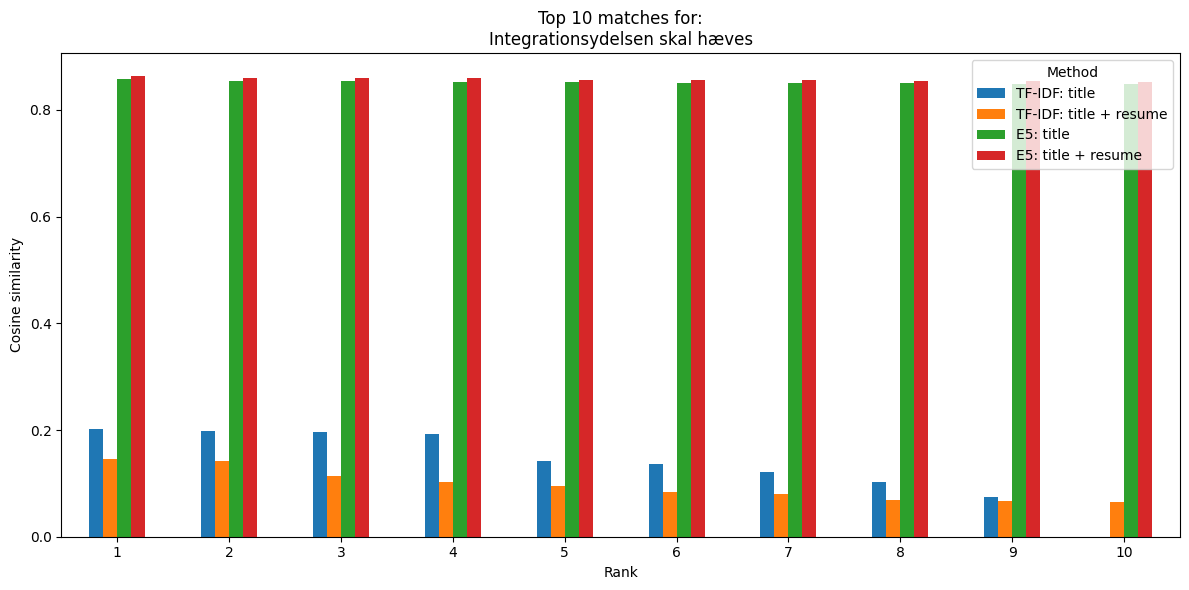

In [123]:
ax = comparison.set_index("Rank").plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_xlabel("Rank")
ax.set_ylabel("Cosine similarity")
ax.set_title(
    f"Top 10 matches for:\n{question}"
)

ax.legend(title="Method")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [124]:
normalized = comparison.copy()

for col in normalized.columns[1:]:
    normalized[col] = normalized[col] / normalized[col].max()

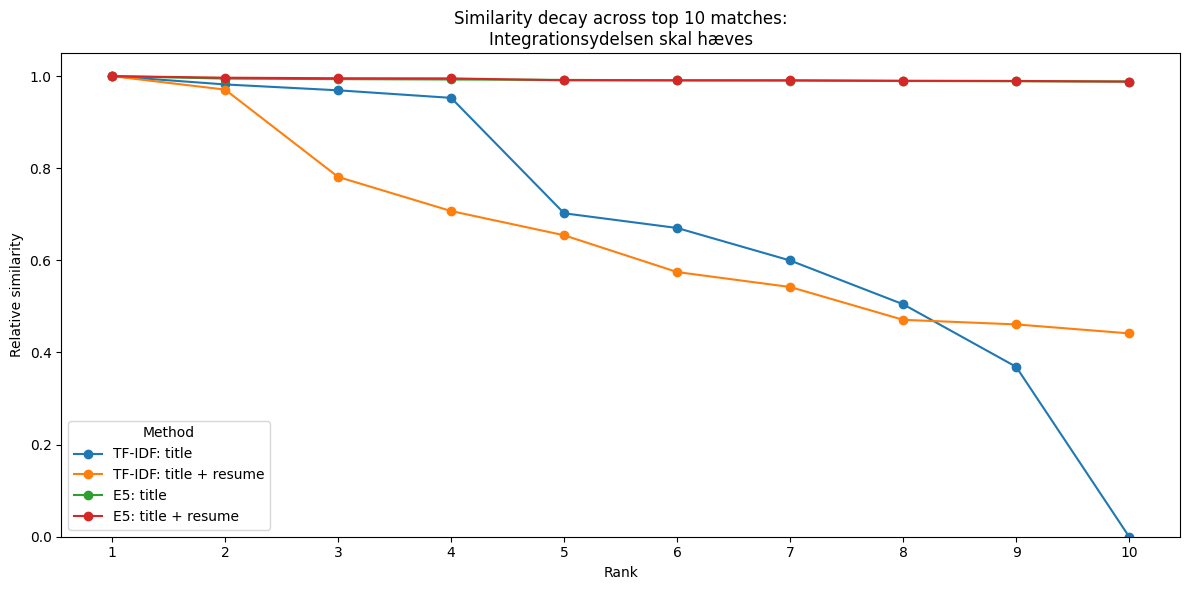

In [125]:
ax = normalized.set_index("Rank").plot(
    figsize=(12, 6),
    marker="o"
)

ax.set_xlabel("Rank")
ax.set_ylabel("Relative similarity")
ax.set_title(
    f"Similarity decay across top 10 matches:\n{question}"
)

ax.legend(title="Method")
plt.xticks(range(1, 11))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()